In [8]:
# Open the original file for reading
with open("dataset/P100_No_Reacg2.txt", "r") as text_file:
    # Read all lines into a list
    lines = text_file.readlines()

# Check if there are lines in the file
if len(lines) > 0:
    # Create a new file name with "n" added
    new_filename = "dataset/P100_No_Reacg2n.txt"

    # Open the new file for writing
    with open(new_filename, "w") as new_file:
        # Write all lines except the first one to the new file
        new_file.writelines(lines[1:])

    print(f"New file '{new_filename}' created with lines except the first one.")
else:
    print("The original file is empty.")

New file 'dataset/P100_No_Reacg2n.txt' created with lines except the first one.


In [9]:
# read the file again store each line in a list
text_file = open("dataset/P100_No_Reacg2n.txt", "r")

lines = text_file.readlines()

# no of lines
print('No of lines in file is ',format(len(lines)))

# print each line text
for line in lines :
    print(line)

# close the file
text_file.close()

No of lines in file is  1800
1,1,White,4

2,2,White,830

3,3,White,822

4,4,White,832

5,5,White,832

6,6,White,823

7,7,White,833

8,8,White,826

9,9,White,828

10,10,White,831

11,11,White,818

12,12,White,834

13,13,White,829

14,14,White,831

15,1,Red,832

16,2,Red,343

17,3,Red,343

18,4,Red,343

19,5,Red,336

20,6,Red,343

21,7,Red,343

22,8,Red,345

23,9,Red,346

24,10,Red,348

25,11,Red,345

26,12,Red,341

27,13,Red,347

28,14,Red,339

29,15,Red,342

30,1,Green,338

31,2,Green,197

32,3,Green,198

33,4,Green,195

34,5,Green,197

35,6,Green,202

36,7,Green,198

37,8,Green,199

38,9,Green,199

39,10,Green,201

40,11,Green,201

41,12,Green,201

42,13,Green,201

43,14,Green,202

44,15,Green,197

45,1,Blue,202

46,2,Blue,336

47,3,Blue,335

48,4,Blue,337

49,5,Blue,337

50,6,Blue,337

51,7,Blue,337

52,8,Blue,333

53,9,Blue,331

54,10,Blue,337

55,11,Blue,332

56,12,Blue,336

57,13,Blue,334

58,14,Blue,331

59,1,Black,335

60,2,Black,6

61,3,Black,7

62,4,Black,5

63,5,Black,5

64,6

In [10]:
import csv

# Open the text file for reading
with open("dataset/P100_No_Reacg2n.txt", "r") as text_file:
    lines = text_file.readlines()

# Remove leading/trailing whitespace from each line and split on a delimiter (e.g., comma)
data = [line.strip().split(',') for line in lines]

# Determine the output file name by replacing the ".txt" extension with ".csv"
output_file_name = "datasetCSV/P100_No_Reacg2n.csv"

# Write the data to a CSV file
with open(output_file_name, "w", newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerows(data)

print(f"File '{output_file_name}' has been created with the CSV data.")


File 'datasetCSV/P100_No_Reacg2n.csv' has been created with the CSV data.


In [ ]:
import pandas as pd

# Define the column names
column_names = ["No.", "Order", "Color", "Value"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Print specific columns
columns_to_print = ["No.", "Order", "Color", "Value"]
print(df[columns_to_print])

# Specify the new file path and save the modified DataFrame
new_output_file_path = "datasetCSV/P100_No_Reacg2n.csv"  # Change this path as needed
df.loc[-1] = columns_to_print  # Add the columns_to_print list as the second row
df.index = df.index + 1  # Shift the index to make room for the new row
df.to_csv(new_output_file_path, index=False)

# Print a confirmation message
print(f"DataFrame saved to {new_output_file_path}")


In [11]:
import pandas as pd


# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Delete rows where "Order" is '1'
df = df[df['Order'] != 1]

# Print the remaining data
print(df)

# Specify the new file path and save the modified DataFrame
new_output_file_path = "datasetCSV/P100_No_Reacg2n_modified.csv"  # Change this path as needed
df.to_csv(new_output_file_path, index=False)

# Print a confirmation message
print(f"DataFrame saved to {new_output_file_path}")


       No.  Order  Color  Value
1        2      2  White    830
2        3      3  White    822
3        4      4  White    832
4        5      5  White    832
5        6      6  White    823
...    ...    ...    ...    ...
1795  1796      5  Green    191
1796  1797      6  Green    195
1797  1798      7  Green    196
1798  1799      8  Green    198
1799  1800      9  Green    201

[1697 rows x 4 columns]
DataFrame saved to datasetCSV/P100_No_Reacg2n_modified.csv


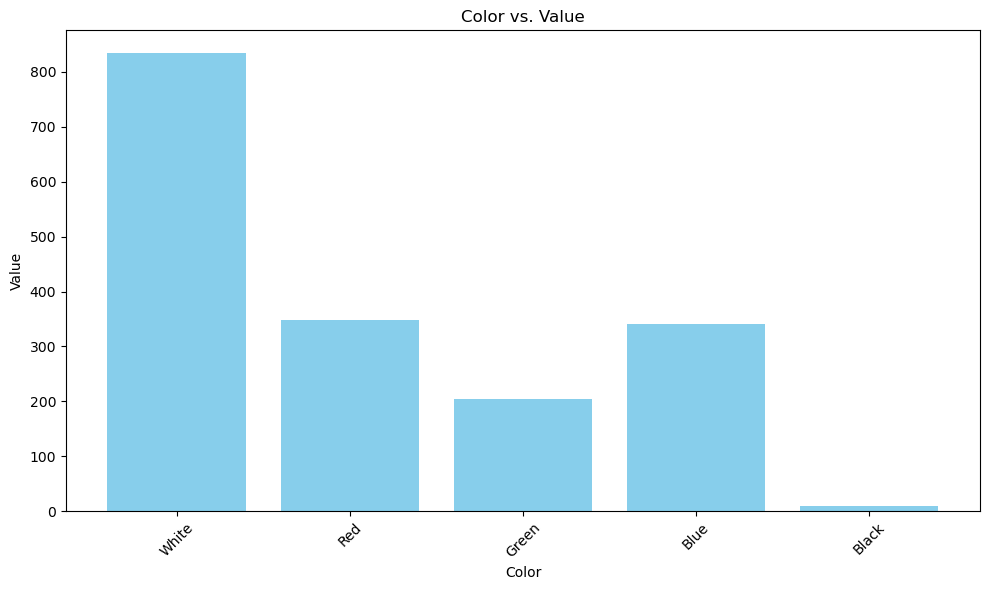

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the modified CSV file
file_path = "datasetCSV/P100_No_Reacg2n_modified.csv"
df = pd.read_csv(file_path)

# Extract the "Color" and "Value" columns
colors = df["Color"]
values = df["Value"]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(colors, values, color='skyblue')
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Color vs. Value")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.tight_layout()
plt.show()


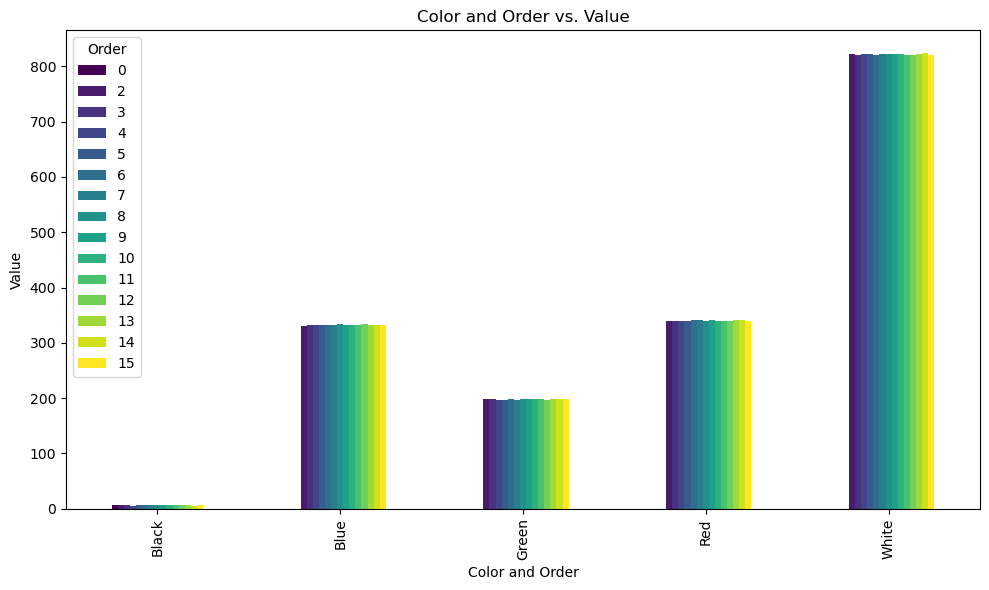

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the modified CSV file
file_path = "datasetCSV/P100_No_Reacg2n_modified.csv"
df = pd.read_csv(file_path)

# Group the data by "Color" and "Order" columns and calculate the mean of "Value"
grouped_df = df.groupby(["Color", "Order"])["Value"].mean().reset_index()

# Pivot the grouped data to create a pivot table
pivot_table = grouped_df.pivot(index="Color", columns="Order", values="Value")

# Create a bar plot
pivot_table.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.xlabel("Color and Order")
plt.ylabel("Value")
plt.title("Color and Order vs. Value")

# Show the plot
plt.tight_layout()
plt.show()
